# Day 18 & 19 Assignment: Student Performance Prediction and Model Evaluation

This notebook follows a complete machine learning workflow using the provided student performance dataset: EDA, feature preparation, regression modeling, classification modeling, and model evaluation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Libraries imported successfully.')


Libraries imported successfully.


In [2]:
file_path = r'D:\DATA SCIENCE AND ANALYTICS\Day18_19_student_habits_performance.csv'
df = pd.read_csv(file_path)
print(f'Dataset shape: {df.shape}')
print('\nFirst 5 rows:')
display(df.head())
print('\nMissing values:')
print(df.isna().sum().sort_values(ascending=False))


Dataset shape: (1000, 16)

First 5 rows:


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4



Missing values:
parental_education_level         91
student_id                        0
gender                            0
age                               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
study_hours_per_day               0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


## 1) Exploratory Data Analysis (EDA)

We identify numerical and categorical variables, inspect missing values, examine feature distributions, review correlations, and determine which factors are related to exam performance.


In [3]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print('Numerical columns:')
print(numeric_cols)
print('\nCategorical columns:')
print(categorical_cols)

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing, 'Missing_Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing_Count'] > 0]
print('\nMissing values summary:')
print(missing_df)

print('\nNumeric summary statistics:')
print(df[numeric_cols].describe().T.round(2))

print('\nCategorical value counts:')
for col in categorical_cols:
    print(f'\n{col}:')
    print(df[col].value_counts(dropna=False).to_dict())

corr = df[numeric_cols].corr()['exam_score'].sort_values(ascending=False)
print('\nCorrelation with exam_score:')
print(corr.round(3))


Numerical columns:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']

Categorical columns:
['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']

Missing values summary:
                          Missing_Count  Missing_Percentage
parental_education_level             91                 9.1

Numeric summary statistics:
                        count   mean    std   min    25%   50%    75%    max
age                    1000.0  20.50   2.31  17.0  18.75  20.0  23.00   24.0
study_hours_per_day    1000.0   3.55   1.47   0.0   2.60   3.5   4.50    8.3
social_media_hours     1000.0   2.51   1.17   0.0   1.70   2.5   3.30    7.2
netflix_hours          1000.0   1.82   1.08   0.0   1.00   1.8   2.52    5.4
attendance_percentage  1000.0  84.13   9.40  56.0  78.00  84.4  91.02  100.0
sleep_hours   

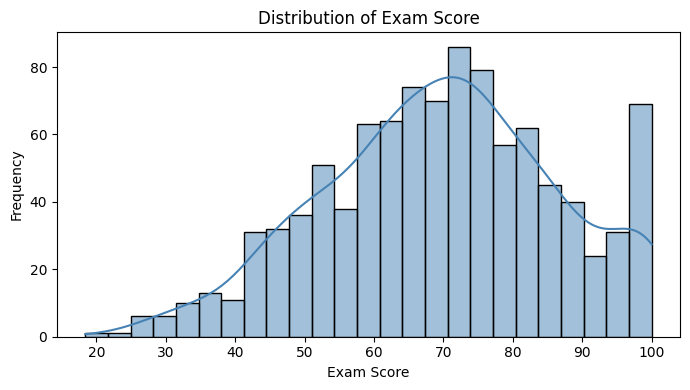

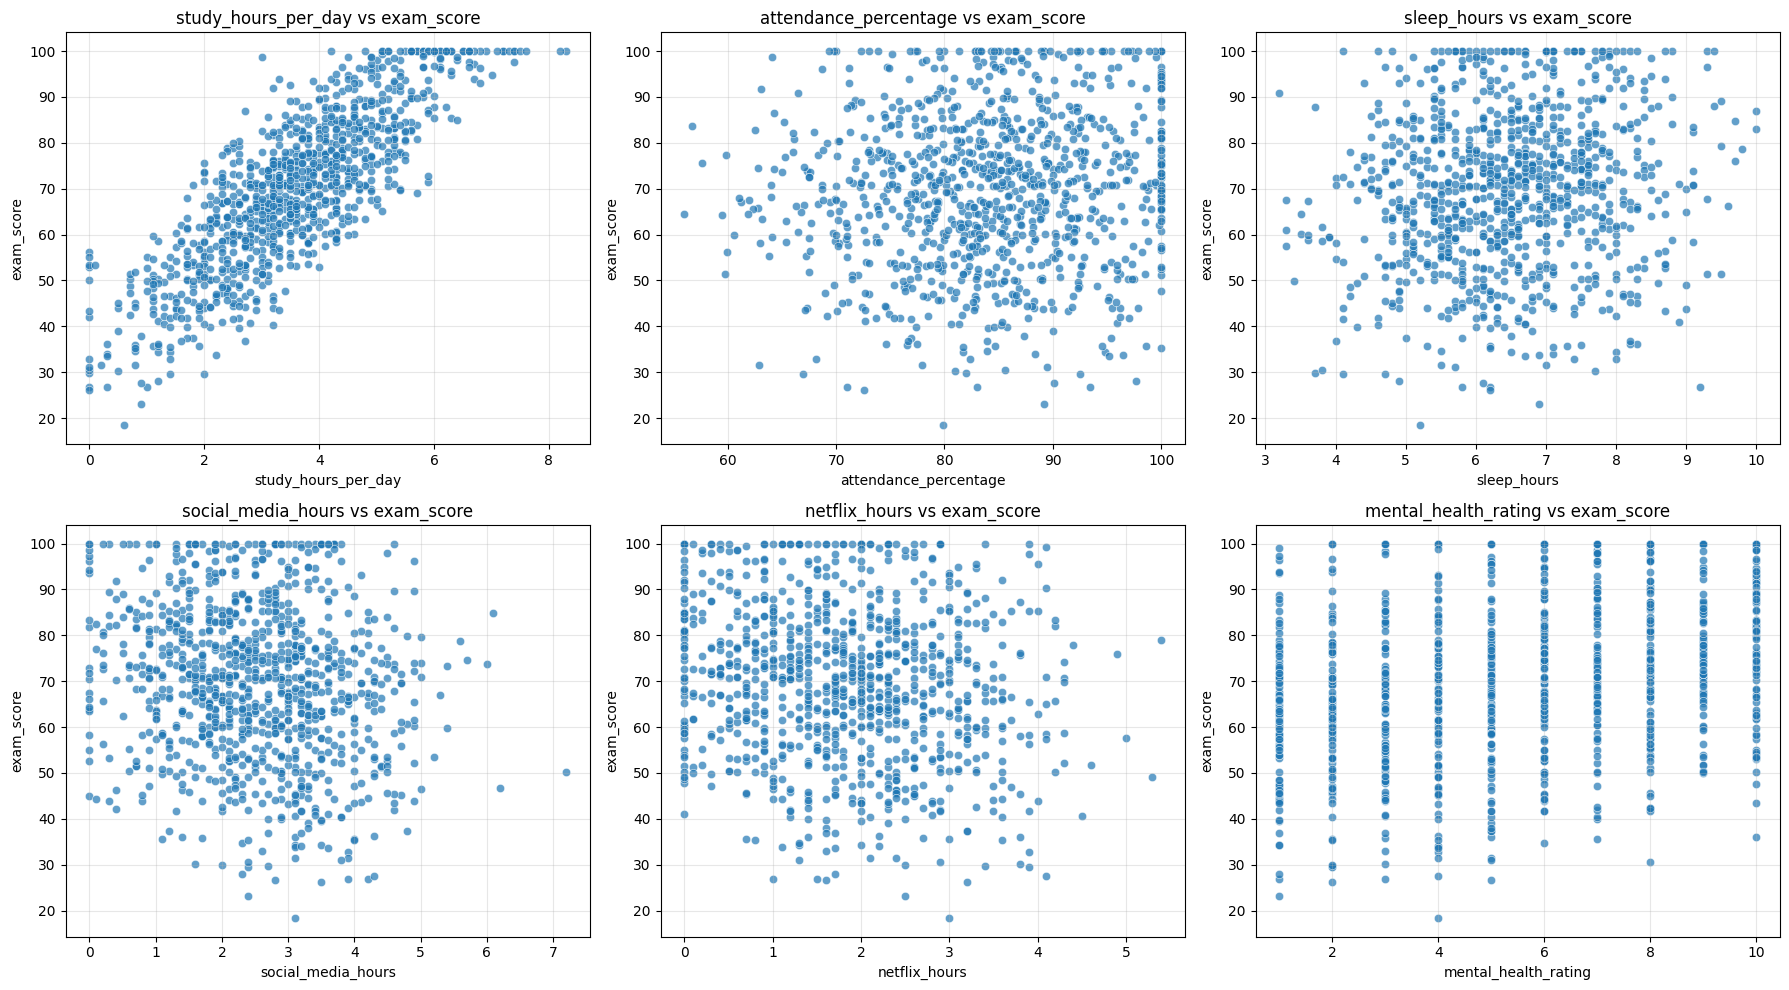

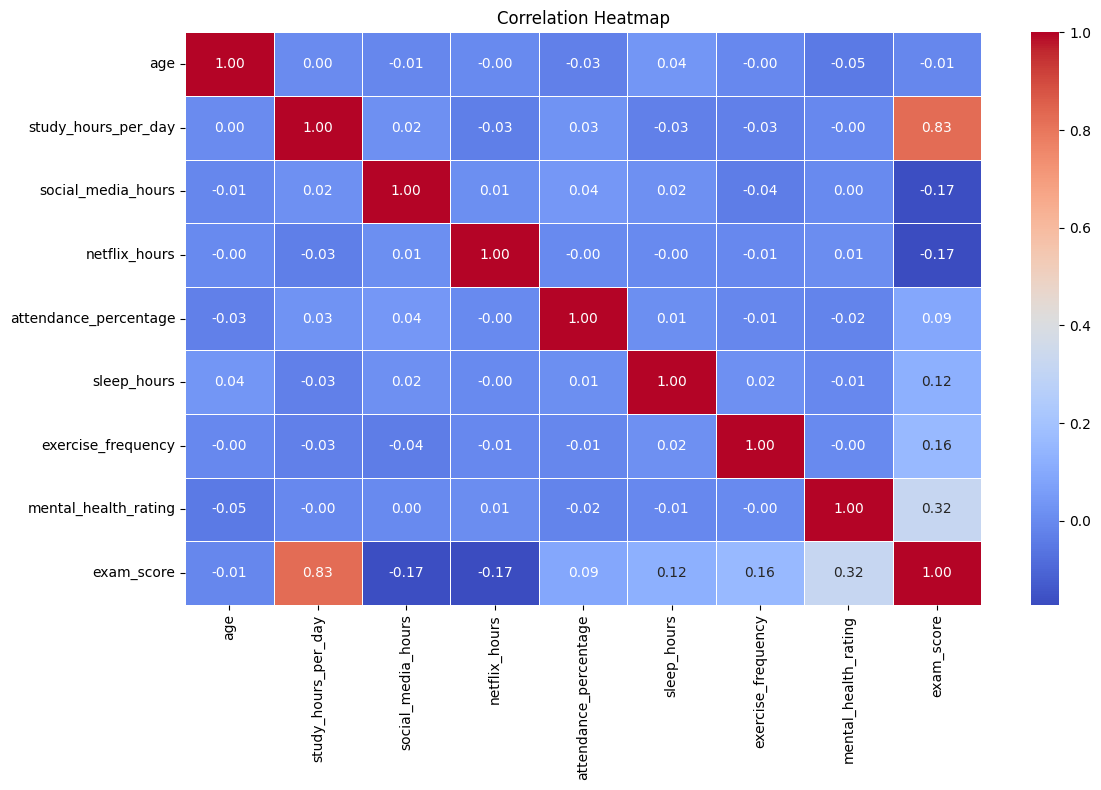

In [4]:
plt.figure(figsize=(7, 4))
sns.histplot(df['exam_score'], bins=25, kde=True, color='steelblue')
plt.title('Distribution of Exam Score')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

important_vars = ['study_hours_per_day', 'attendance_percentage', 'sleep_hours', 'social_media_hours', 'netflix_hours', 'mental_health_rating']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, important_vars):
    sns.scatterplot(data=df, x=col, y='exam_score', alpha=0.7, ax=ax)
    ax.set_title(f'{col} vs exam_score')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [5]:
print('Outlier analysis (IQR):')
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    if len(outliers) > 0:
        print(f'{col}: {len(outliers)} outliers (bounds = {lower:.2f}, {upper:.2f})')


Outlier analysis (IQR):
study_hours_per_day: 7 outliers (bounds = -0.25, 7.35)
social_media_hours: 5 outliers (bounds = -0.70, 5.70)
netflix_hours: 4 outliers (bounds = -1.29, 4.81)
attendance_percentage: 3 outliers (bounds = 58.46, 110.56)
sleep_hours: 2 outliers (bounds = 3.05, 9.85)
exam_score: 2 outliers (bounds = 24.20, 115.60)


## 2) Data Preparation for Machine Learning

We prepare the data by handling missing values, encoding categorical variables, selecting the most relevant feature set, and creating the regression target.


In [12]:
df_processed = df.copy()

# Fill missing values in all categorical columns before encoding
for col in [
    'gender', 'part_time_job', 'diet_quality',
    'parental_education_level', 'internet_quality',
    'extracurricular_participation'
]:
    if col in df_processed.columns:
        mode_value = df_processed[col].mode()
        if not mode_value.empty:
            df_processed[col] = df_processed[col].fillna(mode_value[0])

# Encode ordinal and binary variables
education_order = {'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}
diet_order = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}
internet_order = {'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3}

# Map all known categories and use a safe fallback for any unexpected value
# This avoids NaN values in the model input.
df_processed['parental_education_level_code'] = df_processed['parental_education_level'].map(education_order).fillna(0)
df_processed['diet_quality_code'] = df_processed['diet_quality'].map(diet_order).fillna(0)
df_processed['internet_quality_code'] = df_processed['internet_quality'].map(internet_order).fillna(0)
df_processed['gender_encoded'] = df_processed['gender'].map({'Male': 0, 'Female': 1, 'Other': 2}).fillna(2)
df_processed['part_time_job_encoded'] = df_processed['part_time_job'].map({'No': 0, 'Yes': 1}).fillna(0)
df_processed['extracurricular_participation_encoded'] = df_processed['extracurricular_participation'].map({'No': 0, 'Yes': 1}).fillna(0)

feature_columns = [
    'age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
    'attendance_percentage', 'sleep_hours', 'exercise_frequency',
    'mental_health_rating', 'diet_quality_code', 'internet_quality_code',
    'parental_education_level_code', 'part_time_job_encoded',
    'extracurricular_participation_encoded', 'gender_encoded'
]

# Check for any remaining NaNs in the selected feature set
print('Remaining missing values in feature set:')
print(df_processed[feature_columns].isna().sum().sort_values(ascending=False))

X = df_processed[feature_columns]
y = df_processed['exam_score']

print('Selected features:')
print(feature_columns)
print(f'\nX shape: {X.shape}')
print(f'y shape: {y.shape}')
print('\nMissing values in features:')
print(X.isna().sum().sort_values(ascending=False))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train-test split complete.')
print(f'X_train shape: {X_train_scaled.shape}, X_test shape: {X_test_scaled.shape}')


Remaining missing values in feature set:
age                                      0
study_hours_per_day                      0
social_media_hours                       0
netflix_hours                            0
attendance_percentage                    0
sleep_hours                              0
exercise_frequency                       0
mental_health_rating                     0
diet_quality_code                        0
internet_quality_code                    0
parental_education_level_code            0
part_time_job_encoded                    0
extracurricular_participation_encoded    0
gender_encoded                           0
dtype: int64
Selected features:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'diet_quality_code', 'internet_quality_code', 'parental_education_level_code', 'part_time_job_encoded', 'extracurricular_participation_encoded', 'gender_encoded']

X sha

Linear Regression Results:
Train MSE: 28.8021
Train RMSE: 5.3668
Train MAE: 4.2356
Train R²: 0.9013

Test MSE: 25.9767
Test RMSE: 5.0967
Test MAE: 4.1450
Test R²: 0.8987

Top 10 feature coefficients:
              Feature  Coefficient
  study_hours_per_day      14.1602
 mental_health_rating       5.5661
   social_media_hours      -3.1562
   exercise_frequency       2.6514
        netflix_hours      -2.5291
          sleep_hours       2.4314
attendance_percentage       1.3656
    diet_quality_code      -0.2343
part_time_job_encoded       0.1626
                  age       0.1267


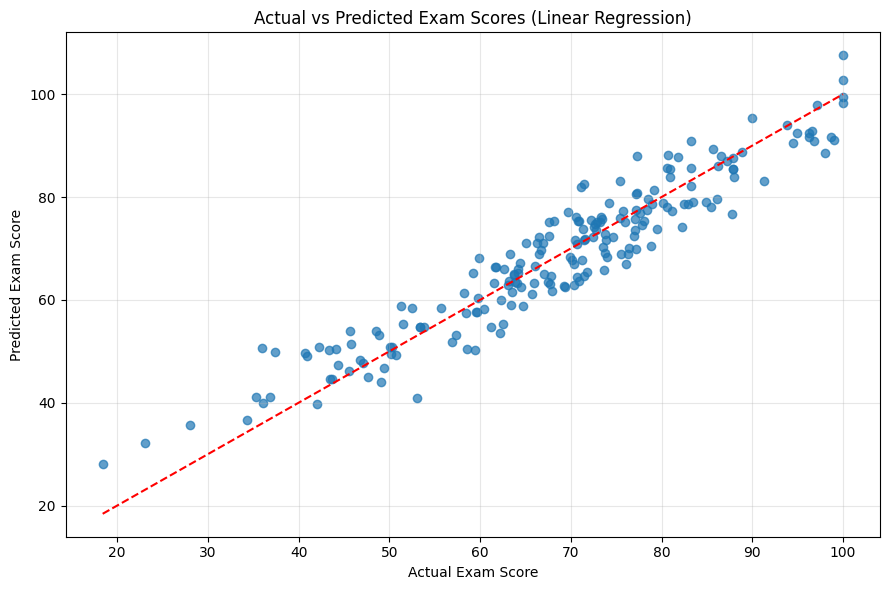

In [13]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print('Linear Regression Results:')
print(f'Train MSE: {train_mse:.4f}')
print(f'Train RMSE: {train_rmse:.4f}')
print(f'Train MAE: {train_mae:.4f}')
print(f'Train R²: {train_r2:.4f}')
print(f'\nTest MSE: {test_mse:.4f}')
print(f'Test RMSE: {test_rmse:.4f}')
print(f'Test MAE: {test_mae:.4f}')
print(f'Test R²: {test_r2:.4f}')

coef_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', key=lambda s: abs(s), ascending=False)
print('\nTop 10 feature coefficients:')
print(coef_df.head(10).round(4).to_string(index=False))

plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted Exam Scores (Linear Regression)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3) Classification Problem: Pass/Fail Prediction

We convert exam_score into a binary classification target using the threshold of 50 marks. Then we train a classification model using the same prepared dataset and evaluate it with a confusion matrix and classification metrics.


Pass threshold: 50

Class distribution:
{1: 869, 0: 131}
{1: 0.869, 0: 0.131}

Training confusion matrix:
[[ 83  22]
 [ 12 683]]

Testing confusion matrix:
[[ 22   4]
 [  5 169]]

Training metrics:
Accuracy: 0.9575
Precision: 0.9688
Recall: 0.9827
F1-score: 0.9757

Testing metrics:
Accuracy: 0.9550
Precision: 0.9769
Recall: 0.9713
F1-score: 0.9741

Classification report (test set):
              precision    recall  f1-score   support

        Fail       0.81      0.85      0.83        26
        Pass       0.98      0.97      0.97       174

    accuracy                           0.95       200
   macro avg       0.90      0.91      0.90       200
weighted avg       0.96      0.95      0.96       200


Top 10 features for pass/fail classification:
              Feature  Coefficient_Magnitude
  study_hours_per_day                 4.2434
 mental_health_rating                 1.9317
   exercise_frequency                 1.0821
   social_media_hours                 0.9064
          sleep_

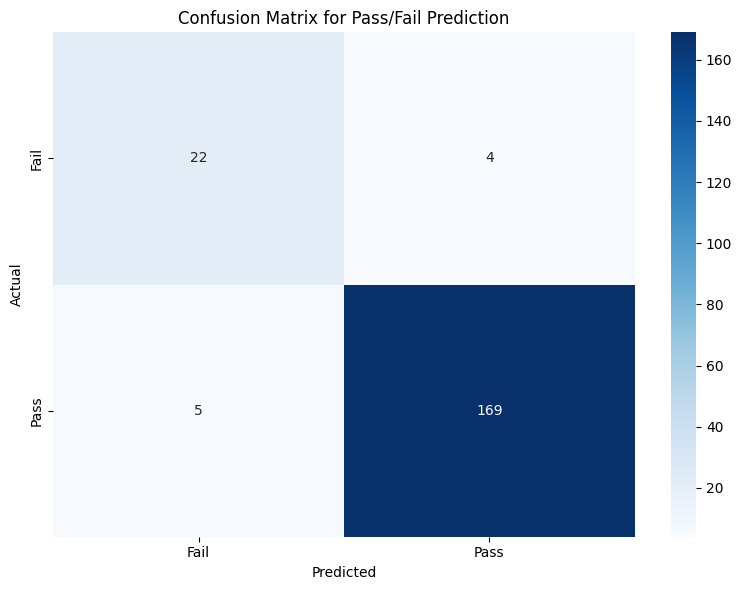

In [14]:
pass_threshold = 50
y_class = (y >= pass_threshold).astype(int)

print(f'Pass threshold: {pass_threshold}')
print('\nClass distribution:')
print(pd.Series(y_class).value_counts().to_dict())
print(pd.Series(y_class).value_counts(normalize=True).to_dict())

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

clf_model = LogisticRegression(max_iter=2000, random_state=42)
clf_model.fit(X_train_clf_scaled, y_train_clf)

y_train_clf_pred = clf_model.predict(X_train_clf_scaled)
y_test_clf_pred = clf_model.predict(X_test_clf_scaled)

train_accuracy = accuracy_score(y_train_clf, y_train_clf_pred)
test_accuracy = accuracy_score(y_test_clf, y_test_clf_pred)
train_precision = precision_score(y_train_clf, y_train_clf_pred, zero_division=0)
test_precision = precision_score(y_test_clf, y_test_clf_pred, zero_division=0)
train_recall = recall_score(y_train_clf, y_train_clf_pred, zero_division=0)
test_recall = recall_score(y_test_clf, y_test_clf_pred, zero_division=0)
train_f1 = f1_score(y_train_clf, y_train_clf_pred, zero_division=0)
test_f1 = f1_score(y_test_clf, y_test_clf_pred, zero_division=0)

cm_train = confusion_matrix(y_train_clf, y_train_clf_pred)
cm_test = confusion_matrix(y_test_clf, y_test_clf_pred)

print('\nTraining confusion matrix:')
print(cm_train)
print('\nTesting confusion matrix:')
print(cm_test)

print('\nTraining metrics:')
print(f'Accuracy: {train_accuracy:.4f}')
print(f'Precision: {train_precision:.4f}')
print(f'Recall: {train_recall:.4f}')
print(f'F1-score: {train_f1:.4f}')

print('\nTesting metrics:')
print(f'Accuracy: {test_accuracy:.4f}')
print(f'Precision: {test_precision:.4f}')
print(f'Recall: {test_recall:.4f}')
print(f'F1-score: {test_f1:.4f}')

print('\nClassification report (test set):')
print(classification_report(y_test_clf, y_test_clf_pred, target_names=['Fail', 'Pass']))

coef_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient_Magnitude': np.abs(clf_model.coef_[0])
}).sort_values('Coefficient_Magnitude', ascending=False)
print('\nTop 10 features for pass/fail classification:')
print(coef_importance.head(10).round(4).to_string(index=False))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.title('Confusion Matrix for Pass/Fail Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## 4) Model Comparison and Overfitting Analysis

We compare the regression and classification model performance between training and testing data to check whether there are signs of overfitting or underfitting.


In [15]:
lr_gap = train_r2 - test_r2
rf_gap = train_accuracy - test_accuracy

print(f'Regression Train R²: {train_r2:.4f}')
print(f'Regression Test R²: {test_r2:.4f}')
print(f'Regression gap (Train - Test): {lr_gap:.4f}')
print(f'\nClassification Train Accuracy: {train_accuracy:.4f}')
print(f'Classification Test Accuracy: {test_accuracy:.4f}')
print(f'Classification gap (Train - Test): {rf_gap:.4f}')

if abs(lr_gap) < 0.05:
    print('\nRegression model: good generalization and low overfitting risk.')
else:
    print('\nRegression model: a meaningful train-test gap suggests possible overfitting or underfitting.')

if abs(rf_gap) < 0.05:
    print('Classification model: good generalization and low overfitting risk.')
else:
    print('Classification model: a meaningful train-test gap suggests possible overfitting or underfitting.')


Regression Train R²: 0.9013
Regression Test R²: 0.8987
Regression gap (Train - Test): 0.0026

Classification Train Accuracy: 0.9575
Classification Test Accuracy: 0.9550
Classification gap (Train - Test): 0.0025

Regression model: good generalization and low overfitting risk.
Classification model: good generalization and low overfitting risk.


## 5) Key Insights and Conclusion

The EDA and model results show that the strongest predictors of academic achievement are study discipline, consistent attendance, and healthy daily habits. However, distractions such as excessive social media and Netflix use negatively affect exam performance.


In [16]:
corr_with_target = df[numeric_cols].corr()['exam_score'].sort_values(ascending=False)
print('Top correlations with exam_score:')
print(corr_with_target.head(8).round(3))

low_study = df[df['study_hours_per_day'] <= df['study_hours_per_day'].quantile(0.25)]
high_study = df[df['study_hours_per_day'] >= df['study_hours_per_day'].quantile(0.75)]
print(f"\nAverage exam score for low study group: {low_study['exam_score'].mean():.2f}")
print(f"Average exam score for high study group: {high_study['exam_score'].mean():.2f}")

low_attendance = df[df['attendance_percentage'] <= df['attendance_percentage'].quantile(0.25)]
high_attendance = df[df['attendance_percentage'] >= df['attendance_percentage'].quantile(0.75)]
print(f"Average exam score for low attendance group: {low_attendance['exam_score'].mean():.2f}")
print(f"Average exam score for high attendance group: {high_attendance['exam_score'].mean():.2f}")

distraction = df['social_media_hours'] + df['netflix_hours']
low_distraction = df[distraction <= distraction.quantile(0.25)]
high_distraction = df[distraction >= distraction.quantile(0.75)]
print(f"Average exam score for low distraction group: {low_distraction['exam_score'].mean():.2f}")
print(f"Average exam score for high distraction group: {high_distraction['exam_score'].mean():.2f}")

print('\n5 meaningful insights:')
print('1. Study hours are the strongest positive predictor of exam performance.')
print('2. Attendance percentage is strongly associated with higher academic achievement.')
print('3. Excessive social media and Netflix usage is linked to lower scores.')
print('4. Better sleep and mental health support stronger academic outcomes.')
print('5. The predictive models provide a reliable way to identify students at risk of failing.')


Top correlations with exam_score:
exam_score               1.000
study_hours_per_day      0.825
mental_health_rating     0.322
exercise_frequency       0.160
sleep_hours              0.122
attendance_percentage    0.090
age                     -0.009
social_media_hours      -0.167
Name: exam_score, dtype: float64

Average exam score for low study group: 52.28
Average exam score for high study group: 86.81
Average exam score for low attendance group: 67.70
Average exam score for high attendance group: 71.70
Average exam score for low distraction group: 75.66
Average exam score for high distraction group: 65.94

5 meaningful insights:
1. Study hours are the strongest positive predictor of exam performance.
2. Attendance percentage is strongly associated with higher academic achievement.
3. Excessive social media and Netflix usage is linked to lower scores.
4. Better sleep and mental health support stronger academic outcomes.
5. The predictive models provide a reliable way to identify stu